# PARMA: Python-wrapped CARMA
## Example notebook for PARMA box model
This is an example of how to run the CARMA box model interface using carma_box, compiled using f2py. For more information on how to run PARMA, see the README in the interfaces directory.

Author: Parker Case

Version: v0.1 (2023/10/13)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from time import perf_counter
from carma_box import carma_box
import carma_tools.carmabins as carmabins
from carma_tools.wetr import grow_v75

### Simulation parameters

In [2]:
nt         = 768    # Number of timesteps (8 days)
dt         = 900    # 900 second timestep
t          = 220    # Temperature
p          = 2400   # Bar
h2o        = 125e-6 # Water vapor mass mixing ratio
h2so4      = 4.7e-10 # Sulfuric acid vapor mass mixing ratio
su         = np.asarray(
             [4.2579942e-28, 1.5634370e-27, 1.1281235e-26, 7.5493089e-24, 4.6745146e-22,
              1.1954208e-20, 1.5612010e-19, 1.3430505e-18, 2.1747372e-17, 1.5991898e-15,
              6.5651301e-14, 1.1735656e-12, 1.3214742e-11, 7.1381352e-11, 2.0359722e-10,
              3.1819103e-10, 1.3236401e-10, 1.2854880e-11, 3.6080232e-13, 2.5853792e-15,
              4.4601091e-18, 2.1512019e-21, 2.8390088e-25, 5.5137755e-29]
             )
su_0       = su.copy()

### CARMA bin structure

In [3]:
nbins = 24
rmrat = 3.7515201
rmin  = 2.6686863e-8 # cm
rhop  = 1.923 # g cm-3

### Run the model!

In [4]:
time_0 = perf_counter()
carma_box(rmrat, rmin, rhop, t, p, h2so4, h2o, su, dt, nt, nbins)
time_1 = perf_counter()
print('CARMA took ' + str(time_1-time_0) + ' seconds to run ' + str(nt) + ' timesteps.')
print('Time per timestep = ' + str((time_1-time_0)/nt) + ' seconds')

CARMA took 0.35434525506570935 seconds to run 768 timesteps.
Time per timestep = 0.00046138705086680903 seconds


### Convert to mKs units for analysis

In [5]:
rhop = rhop * 1000 # kg m-3
rmin = rmin * 1e-2 # m

### Build CARMA bin structure for analysis

In [6]:
airdensity = 0.188 # kg m-3
rmass, rmassup, r, rup, dr, rlow, masspart = carmabins.carmabins(nbins, rmrat, rmin, rhop)
dndr_in  = su_0 / dr / (4/3 * np.pi * r**3 * rhop) * airdensity
dndr_out = su / dr / (4/3 * np.pi * r**3 * rhop) * airdensity

### Plot size distributions

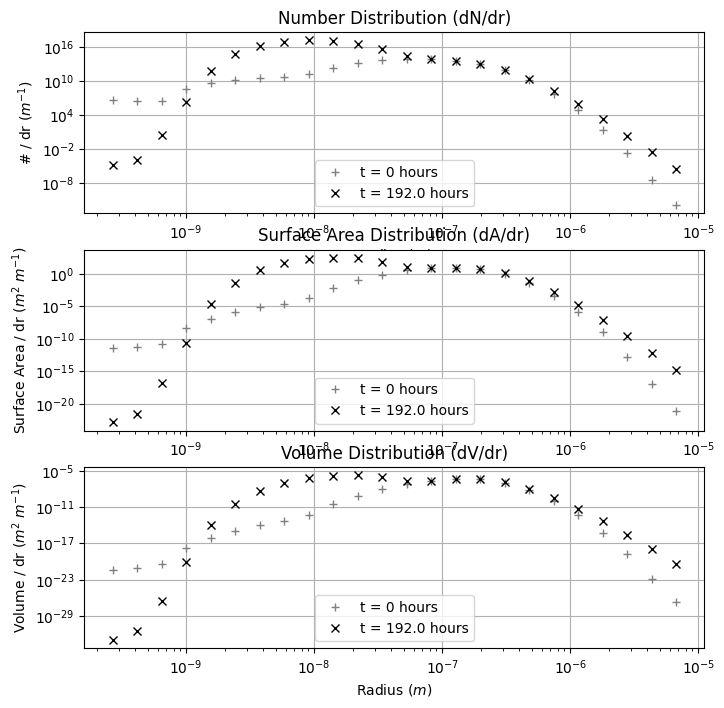

In [7]:
fig, axs = plt.subplots(3,1, figsize=(8,8))

axs[0].loglog(r, dndr_in, '+', color='grey', label='t = 0 hours')
axs[0].loglog(r, dndr_out, 'x', color='black', label='t = ' + str(nt*dt/3600) + ' hours')
axs[0].legend()
axs[0].set_title('Number Distribution (dN/dr)')
axs[0].set_xlabel('Radius ($m$)')
axs[0].set_ylabel('# / dr ($m^{-1}$)')
axs[0].grid()

axs[1].loglog(r, 4*np.pi*r**2*dndr_in, '+', color='grey', label='t = 0 hours')
axs[1].loglog(r, 4*np.pi*r**2*dndr_out, 'x', color='black', label='t = ' + str(nt*dt/3600) + ' hours')
axs[1].legend()
axs[1].set_title('Surface Area Distribution (dA/dr)')
axs[1].set_xlabel('Radius ($m$)')
axs[1].set_ylabel('Surface Area / dr ($m^2\ m^{-1}$)')
axs[1].grid()

axs[2].loglog(r, 4/3*np.pi*r**3*dndr_in, '+', color='grey', label='t = 0 hours')
axs[2].loglog(r, 4/3*np.pi*r**3*dndr_out, 'x', color='black', label='t = ' + str(nt*dt/3600) + ' hours')
axs[2].legend()
axs[2].set_title('Volume Distribution (dV/dr)')
axs[2].set_xlabel('Radius ($m$)')
axs[2].set_ylabel('Volume / dr ($m^2\ m^{-1}$)')
axs[2].grid()